## Load libraries and set project directory

In [15]:
# Load libraries
import pandas as pd
import gseapy as gp
from gseapy import barplot, dotplot, heatmap
from gseapy import Msigdb
import matplotlib.pyplot as plt
import os
import numpy as np
import statsmodels.stats.multitest
#.stats.multitest.fdrcorrection(pvals, alpha=0.05, method='indep', is_sorted=False)[source]
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind
import networkx as nx
import random
from sklearn import linear_model
from sklearn import linear_model
import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist
%matplotlib inline

# Set project directory as working directory
project_dir = "/lab-share/Pulmonary-Chun-e2/Public/data/czi_integration"
os.chdir(project_dir)

# Prep data

## Read in differential gene list

The differential genes are comparing in NPC2 vs Control samples for both AT2 cells and macrophage cells.

In [16]:
# Read in data
de_genes_at2 = pd.read_csv("output/08_de_at2_vs_ctrl.csv")
de_genes_macs = pd.read_csv("output/08_de_macs_vs_ctrl.csv")

de_genes_at2.columns.values[0] = "gene_symbol"
de_genes_macs.columns.values[0] = "gene_symbol"

print(de_genes_at2.head())
print(de_genes_macs.head())

  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj
0       DTHD1  8.825132e-278   -3.656918  0.306  0.104  1.544398e-274
1      LMNTD1  1.879619e-219   -1.045546  0.427  0.192  3.289333e-216
2    KIAA1211  3.240984e-183   -8.585989  0.622  0.333  5.671722e-180
3       CHST9  1.870905e-166   -4.316990  0.415  0.212  3.274084e-163
4    CABCOCO1  2.251106e-158   -0.104351  0.335  0.157  3.939435e-155
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj
0   MTRNR2L12   0.000000e+00    4.192338  0.756  0.088   0.000000e+00
1        XIST   0.000000e+00  -12.668980  0.000  0.642   0.000000e+00
2      HS3ST2   0.000000e+00    5.056330  0.514  0.014   0.000000e+00
3      TCF7L2  1.615220e-264   -3.323688  0.319  0.792  5.066784e-260
4      FNDC3B  1.311863e-256   -1.922318  0.712  0.932  4.115185e-252


## Filter data

In [17]:
# Process data
de_genes_at2 = de_genes_at2[de_genes_at2["gene_symbol"] != "-"]  # remove genes with missing symbols
de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"].notna()] # remove genes with missing pvalues

de_genes_macs = de_genes_macs[de_genes_macs["gene_symbol"] != "-"]  # remove genes with missing symbols
de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"].notna()] # remove genes with missing pvalues

# Filter to DE genes with a adjusted p-value < 0.05 and 0.01
## AT2
padj01de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"] < 0.1]
padj005de_genes_at2 = de_genes_at2[de_genes_at2["p_val_adj"] < 0.05]

print(len(padj01de_genes_at2))
print(len(padj005de_genes_at2))

## Macrophages
padj01de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"] < 0.1]
padj005de_genes_macs = de_genes_macs[de_genes_macs["p_val_adj"] < 0.05]

print(len(padj01de_genes_macs))
print(len(padj005de_genes_macs))

922
895
4993
4808


## Rank genes by log2 fold change

You need to separate by positive and negative because positive log2fc gets a positive score and vice versa and then the two separated rankings get combined.
The bigger the absolute value of the ranking, the bigger absolute value fo the log2fc.

### AT2 Cells

In [18]:
# Sort by log2fc
de_genes_at2 = de_genes_at2.sort_values("avg_log2FC", ascending = False)

# Split into positive and negative log2fc, rank accordingly
num_pos_genes_at2 = len(de_genes_at2[de_genes_at2["avg_log2FC"] >= 0])
num_list_positive_log2fc_at2 = list(range(num_pos_genes_at2, 0, -1))
num_neg_genes_at2 = len(de_genes_at2[de_genes_at2["avg_log2FC"] < 0])
num_list_negative_log2fc_at2 = list(range(-1, -1 * (num_neg_genes_at2 + 1), -1))

# Add ranks to dataframe
log2fc_ranks = num_list_positive_log2fc_at2 + num_list_negative_log2fc_at2
de_genes_at2["log2fc_ranks"] = log2fc_ranks

### Macrophage Cells

In [19]:
# Sort by log2fc
de_genes_macs = de_genes_macs.sort_values("avg_log2FC", ascending = False)

# Split into positive and negative log2fc, rank accordingly
num_pos_genes_macs = len(de_genes_macs[de_genes_macs["avg_log2FC"] >= 0])
num_list_positive_log2fc_macs = list(range(num_pos_genes_macs, 0, -1))
num_neg_genes_macs = len(de_genes_macs[de_genes_macs["avg_log2FC"] < 0])
num_list_negative_log2fc_macs = list(range(-1, -1 * (num_neg_genes_macs + 1), -1))

# Add ranks to dataframe
log2fc_ranks = num_list_positive_log2fc_macs + num_list_negative_log2fc_macs
de_genes_macs["log2fc_ranks"] = log2fc_ranks

## Rank genes by p-value

Again you have to separate by positive and negative log2fc for the same reasons as above.

You have to use regular p-value instead of adjusted p-value because the adjusted p-value will give less ties; this is especially important for Wilcoxon rank sum tests.

### AT2 Cells

In [20]:
# Transform p-values into -log(pvalues) for easier sorting (more significant genes will have bigger numbers)
minus_log_pval_at2 = list(-np.log10(de_genes_at2["p_val"].tolist()))
de_genes_at2["minus_log10_p_val"] = minus_log_pval_at2

# Sort by p-value
de_genes_at2 = de_genes_at2.sort_values("minus_log10_p_val", ascending = False)

Now that the genes are sorted, we can split them into positive and negative, rank, and then recombine the rankings.

In [21]:
# Split into positive and negative log2fc and rank according to -log(pvalue)
pos_log2fc_at2 = de_genes_at2[de_genes_at2["avg_log2FC"] >= 0]
pos_log2fc_at2["pval_ranks"] = num_list_positive_log2fc_at2 # List already defined above in log2fc ranking step


neg_log2fc_at2 = de_genes_at2[de_genes_at2["avg_log2FC"] < 0]
neg_log2fc_at2 = neg_log2fc_at2.sort_values("minus_log10_p_val", ascending = True)
neg_log2fc_at2["pval_ranks"] = num_list_negative_log2fc_at2

# Add ranks to dataframe
de_genes_at2 = pd.concat([pos_log2fc_at2, neg_log2fc_at2], axis=0)
print(de_genes_at2.head())
print(de_genes_at2.tail())

   gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
5       CFAP47  8.207227e-149    3.417491  0.416  0.228  1.436265e-145   
10      SEMA6A  5.286429e-133    0.683170  0.035  0.062  9.251251e-130   
15        SYN3  4.387201e-123    2.933876  0.216  0.070  7.677601e-120   
19        TBX3  3.796610e-116    3.032769  0.037  0.043  6.644068e-113   
20       TTC29  4.326269e-115    1.325708  0.236  0.130  7.570971e-112   

    log2fc_ranks  minus_log10_p_val  pval_ranks  
5            285         148.085804         412  
10            85         132.276838         411  
15           257         122.357813         410  
19           263         115.420604         409  
20           145         114.363886         408  
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
4    CABCOCO1  2.251106e-158   -0.104351  0.335  0.157  3.939435e-155   
3       CHST9  1.870905e-166   -4.316990  0.415  0.212  3.274084e-163   
2    KIAA1211  3.240984e-183   -8.58

/tmp/ipykernel_882998/1875178422.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_log2fc_at2["pval_ranks"] = num_list_positive_log2fc_at2 # List already defined above in log2fc ranking step


### Macrophage Cells

In [22]:
# Transform p-values into -log(pvalues) for easier sorting (more significant genes will have bigger numbers)
minus_log_pval_macs = list(-np.log10(de_genes_macs["p_val"].tolist()))
de_genes_macs["minus_log10_p_val"] = minus_log_pval_macs

# Sort by p-value
de_genes_macs = de_genes_macs.sort_values("minus_log10_p_val", ascending = False)

/tmp/ipykernel_882998/2302320460.py:2: RuntimeWarning: divide by zero encountered in log10
  minus_log_pval_macs = list(-np.log10(de_genes_macs["p_val"].tolist()))


In [23]:
# Split into positive and negative log2fc and rank according to -log(pvalue)
pos_log2fc_macs = de_genes_macs[de_genes_macs["avg_log2FC"] >= 0]
pos_log2fc_macs["pval_ranks"] = num_list_positive_log2fc_macs # List already defined above in log2fc ranking step

neg_log2fc_macs = de_genes_macs[de_genes_macs["avg_log2FC"] < 0]
neg_log2fc_macs = neg_log2fc_macs.sort_values("minus_log10_p_val", ascending = True)
neg_log2fc_macs["pval_ranks"] = num_list_negative_log2fc_macs

# Add ranks to dataframe
de_genes_macs = pd.concat([pos_log2fc_macs, neg_log2fc_macs], axis=0)
print(de_genes_macs.head())
print(de_genes_macs.tail())

   gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
2       HS3ST2   0.000000e+00    5.056330  0.514  0.014   0.000000e+00   
0    MTRNR2L12   0.000000e+00    4.192338  0.756  0.088   0.000000e+00   
7    LINC01500  3.373849e-210    5.547856  0.341  0.011  1.058343e-205   
8        HMCN1  2.897842e-206    2.356621  0.571  0.130  9.090239e-202   
11         NTM  6.847481e-199    1.784364  0.500  0.092  2.147986e-194   

    log2fc_ranks  minus_log10_p_val  pval_ranks  
2           2063                inf        2089  
0           2039                inf        2088  
7           2071         209.471874        2087  
8           1942         205.537925        2086  
11          1864         198.164469        2085  
  gene_symbol          p_val  avg_log2FC  pct.1  pct.2      p_val_adj  \
6       LSAMP  4.526711e-221   -5.721042  0.166  0.635  1.419984e-216   
5        SVIL  1.006716e-250   -3.010149  0.320  0.780  3.157967e-246   
4      FNDC3B  1.311863e-256   -1.92

/tmp/ipykernel_882998/15624781.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pos_log2fc_macs["pval_ranks"] = num_list_positive_log2fc_macs # List already defined above in log2fc ranking step


# Run GSEA

In [24]:
# MSIGDB (molecular signature database)
msig = Msigdb()

# list msigdb version you wanna query
msig.list_dbver()

# list categories given most recent dbver.
msig.list_category(dbver = "2025.1.Hs")

['c1.all',
 'c2.all',
 'c2.cgp',
 'c2.cp.biocarta',
 'c2.cp.kegg_legacy',
 'c2.cp.kegg_medicus',
 'c2.cp.pid',
 'c2.cp.reactome',
 'c2.cp',
 'c2.cp.wikipathways',
 'c3.all',
 'c3.mir.mir_legacy',
 'c3.mir.mirdb',
 'c3.mir',
 'c3.tft.gtrd',
 'c3.tft.tft_legacy',
 'c3.tft',
 'c4.3ca',
 'c4.all',
 'c4.cgn',
 'c4.cm',
 'c5.all',
 'c5.go.bp',
 'c5.go.cc',
 'c5.go.mf',
 'c5.go',
 'c5.hpo',
 'c6.all',
 'c7.all',
 'c7.immunesigdb',
 'c7.vax',
 'c8.all',
 'h.all',
 'msigdb']

## AT2 Cells

### Hallmark pathways

We will first pick AT2 cells ranked by log2fc.

In [25]:
prerank_list = de_genes_at2.sort_values("log2fc_ranks", ascending = False)
prerank_list[["gene_symbol", "log2fc_ranks"]]

gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/hallmark_at2_log2fc_ranking", # don't write to disk
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:21:18,702 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:21:18,711 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:21:18,711 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-17 12:21:18,712 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:21:18,992 [INFO] Congratulations. GSEApy runs successfully................



In [26]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_COAGULATION,-0.522899,-1.433607,0.020202,0.643196,0.472,16/25,36.77%,DPP4;PRSS23;TIMP1;BMP1;ANXA1;ITGA2;APOC1;F3;CT...
1,prerank,HALLMARK_FATTY_ACID_METABOLISM,-0.561004,-1.392497,0.051742,0.509693,0.631,8/13,28.37%,ACADL;HSP90AA1;PTPRG;BMPR1B;MAOA;MGLL;CD36;ALD...
2,prerank,HALLMARK_ADIPOGENESIS,-0.530579,-1.359988,0.065353,0.472471,0.74,9/16,30.93%,ACADL;PDCD4;PLIN2;MGLL;ABCA1;CD36;LIFR;C3;NABP1
3,prerank,HALLMARK_MTORC1_SIGNALING,-0.522602,-1.237284,0.164882,1.0,0.975,8/11,36.18%,NIBAN1;BCAT1;CTSC;SLA;SLC2A3;RRM2;TFRC;SYTL2
4,prerank,HALLMARK_KRAS_SIGNALING_DN,-0.48162,-1.230256,0.163412,0.897298,0.98,5/16,9.65%,SIDT1;SLC16A7;PTGFR;BMPR1B;CAMK1D


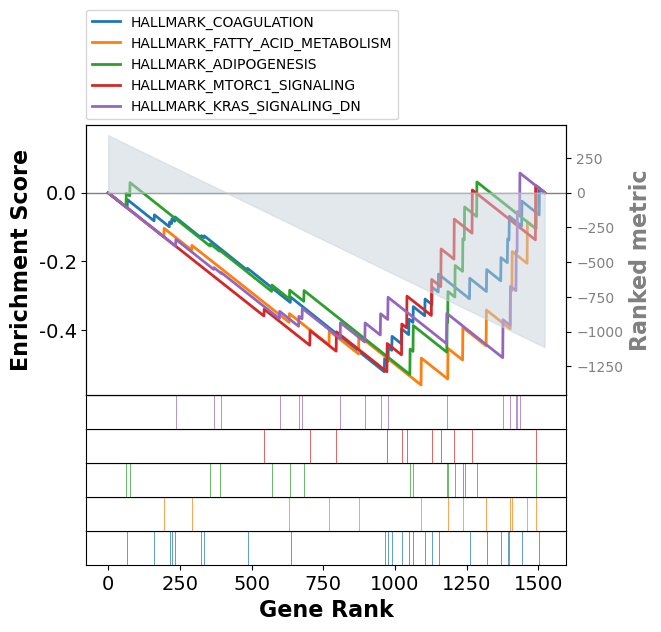

In [27]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

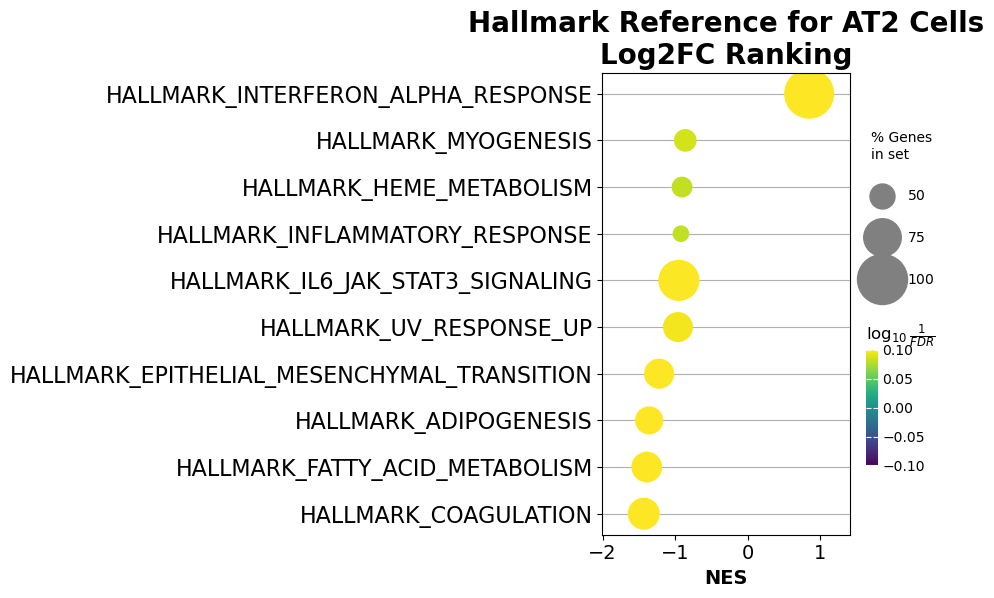

In [28]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='Hallmark Reference for AT2 Cells\nLog2FC Ranking',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

Next we will repeat on AT2 cells using ranking based on -log10(pvalue)

In [29]:
prerank_list = de_genes_at2.sort_values("pval_ranks", ascending = False)
prerank_list[["gene_symbol", "pval_ranks"]]

gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/hallmark_at2_pval_ranking", # don't write to disk
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:21:20,737 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:21:20,744 [INFO] 0017 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:21:20,744 [INFO] 0033 gene_sets used for further statistical testing.....
2025-07-17 12:21:20,745 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:21:21,056 [INFO] Congratulations. GSEApy runs successfully................



#### Visualize Results

In [30]:
pre_res.res2d.head(5)


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_BILE_ACID_METABOLISM,-0.575375,-1.385471,0.06538,1.0,0.676,5/11,19.04%,ABCA1;ALDH1A1;ABCA6;ABCA3;ABCA9
1,prerank,HALLMARK_KRAS_SIGNALING_DN,-0.52437,-1.343515,0.065625,0.845347,0.808,7/16,23.11%,BMPR1B;SGK1;SIDT1;EDN1;SLC16A7;PTGFR;CAMK1D
2,prerank,HALLMARK_ANGIOGENESIS,-0.524161,-1.286071,0.126702,0.956934,0.92,7/13,29.28%,JAG1;TIMP1;FSTL1;VCAN;TNFRSF21;LPL;COL3A1
3,prerank,HALLMARK_G2M_CHECKPOINT,-0.539139,-1.259191,0.15393,0.883094,0.951,7/10,43.01%,SLC38A1;MT2A;EZH2;TOP2A;MEIS2;HIF1A;EFNA5
4,prerank,HALLMARK_APOPTOSIS,-0.444555,-1.22374,0.143001,0.929385,0.977,15/27,36.18%,PLAT;BIRC3;TIMP3;SLC20A1;DCN;ANXA1;PDCD4;TIMP1...


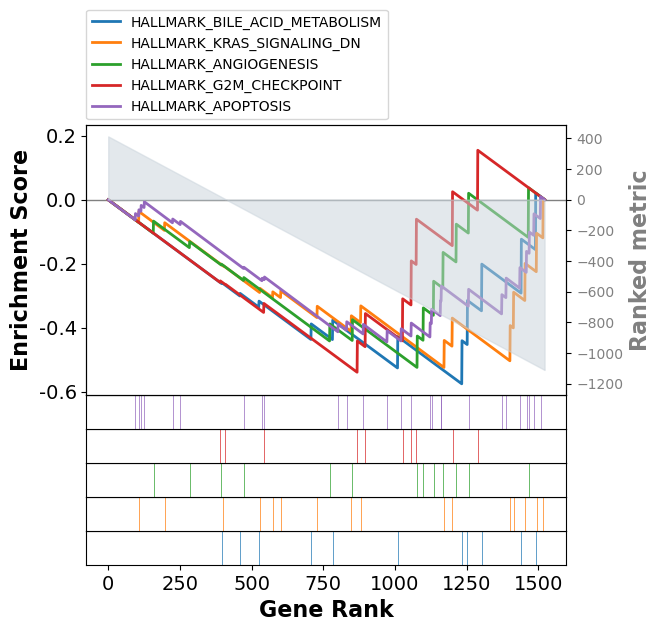

In [31]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )


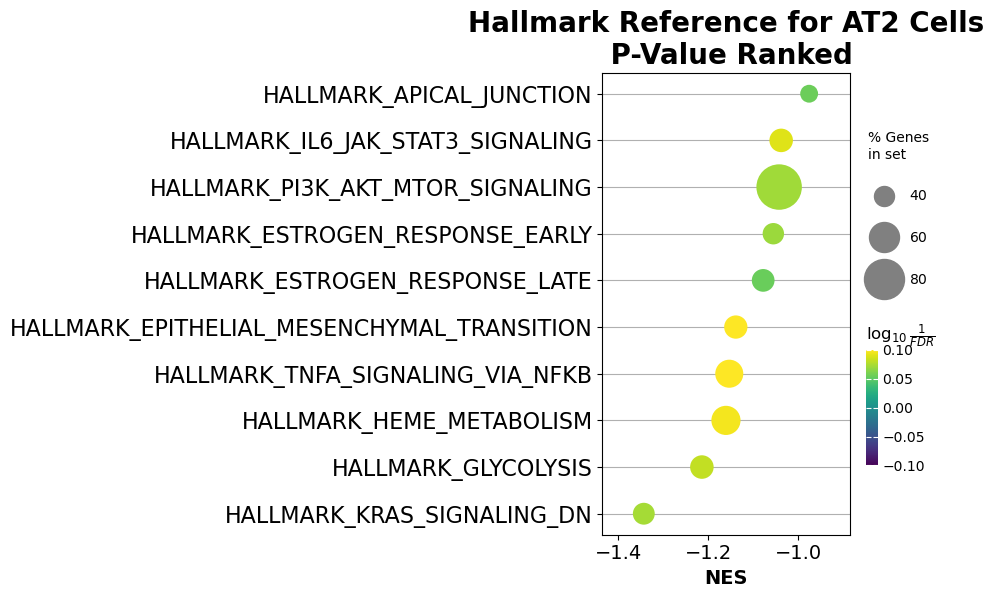

In [32]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='Hallmark Reference for AT2 Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

### KEGG Pathways

Next we will repeat the above using KEGG pathways

In [33]:
gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
prerank_list = de_genes_at2.sort_values("log2fc_ranks", ascending = False)
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/kegg_at2_log2fc_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:21:22,860 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:21:22,868 [INFO] 0127 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:21:22,868 [INFO] 0059 gene_sets used for further statistical testing.....
2025-07-17 12:21:22,869 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:21:23,264 [INFO] Congratulations. GSEApy runs successfully................



In [34]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_LONG_TERM_DEPRESSION,0.407799,1.388533,0.044776,0.589325,0.14,10/10,59.49%,IGF1;IGF1R;GUCY1A2;GRIA1;GNAI1;ITPR2;PRKCA;ITP...
1,prerank,KEGG_COMPLEMENT_AND_COAGULATION_CASCADES,-0.528802,-1.263634,0.154915,1.0,0.985,8/11,36.77%,F13A1;C4BPA;PLAUR;F3;F8;C3;CFH;PLAT
2,prerank,KEGG_AXON_GUIDANCE,-0.439762,-1.202379,0.1643,1.0,1.0,9/28,20.03%,NTN1;ROBO2;LRRC4C;EFNA5;NRP1;SEMA6D;ROBO1;ABLI...
3,prerank,KEGG_PURINE_METABOLISM,-0.457663,-1.167364,0.232198,1.0,1.0,12/16,46.49%,PDE3A;PDE4B;PDE7B;PDE8B;PDE10A;RRM2;PDE4D;PDE1...
4,prerank,KEGG_TGF_BETA_SIGNALING_PATHWAY,-0.460145,-1.120581,0.317098,1.0,1.0,4/13,18.58%,LTBP1;BMPR1B;BMP5;DCN


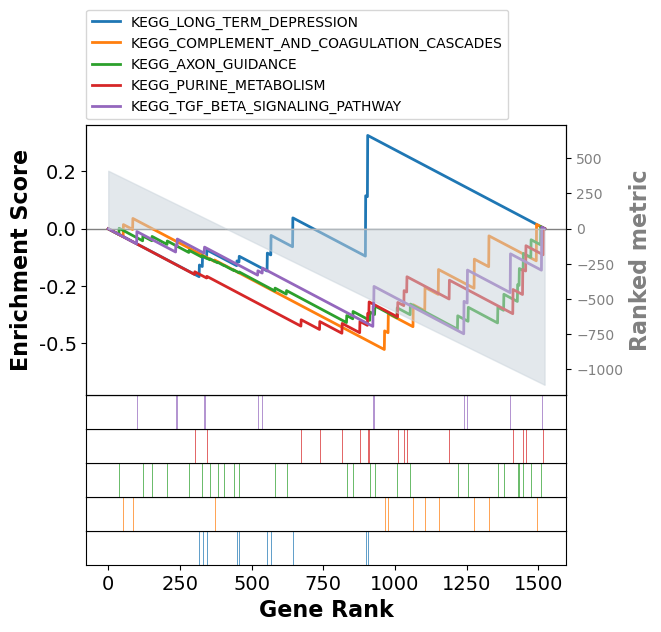

In [35]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

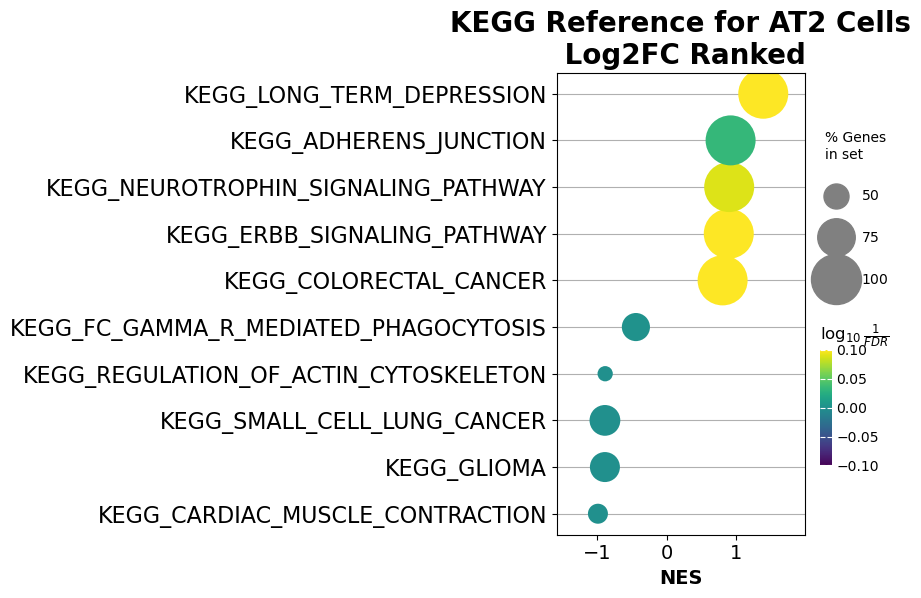

In [36]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG Reference for AT2 Cells\n Log2FC Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

In [37]:
gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
prerank_list = de_genes_at2.sort_values("pval_ranks", ascending = False)
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/kegg_at2_pval_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:21:24,936 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:21:24,944 [INFO] 0127 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:21:24,945 [INFO] 0059 gene_sets used for further statistical testing.....
2025-07-17 12:21:24,945 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:21:25,430 [INFO] Congratulations. GSEApy runs successfully................



In [38]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_TGF_BETA_SIGNALING_PATHWAY,-0.579883,-1.430089,0.036611,1.0,0.703,4/13,7.35%,BMPR1B;LTBP1;DCN;INHBA
1,prerank,KEGG_ABC_TRANSPORTERS,-0.561515,-1.388345,0.058577,1.0,0.817,6/13,19.04%,ABCA13;ABCA1;ABCA10;ABCA6;ABCA3;ABCA9
2,prerank,KEGG_CARDIAC_MUSCLE_CONTRACTION,-0.515904,-1.203491,0.192553,1.0,0.997,5/10,31.58%,CACNB2;MT-CO1;CACNB4;ATP1B1;MT-CO2
3,prerank,KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION,-0.430353,-1.189771,0.172,1.0,0.997,11/31,26.33%,BMPR1B;IL7R;INHBA;IL18R1;PDGFB;TNFRSF1B;VEGFC;...
4,prerank,KEGG_PURINE_METABOLISM,-0.454941,-1.16746,0.240571,1.0,0.999,11/16,42.81%,ADCY4;PDE7B;PDE1C;PDE1A;PDE3A;ADCY3;PDE10A;PDE...


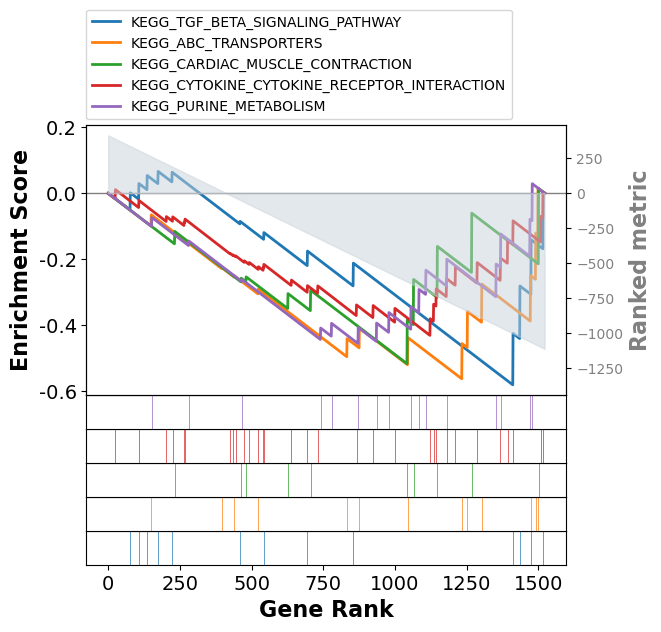

In [39]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

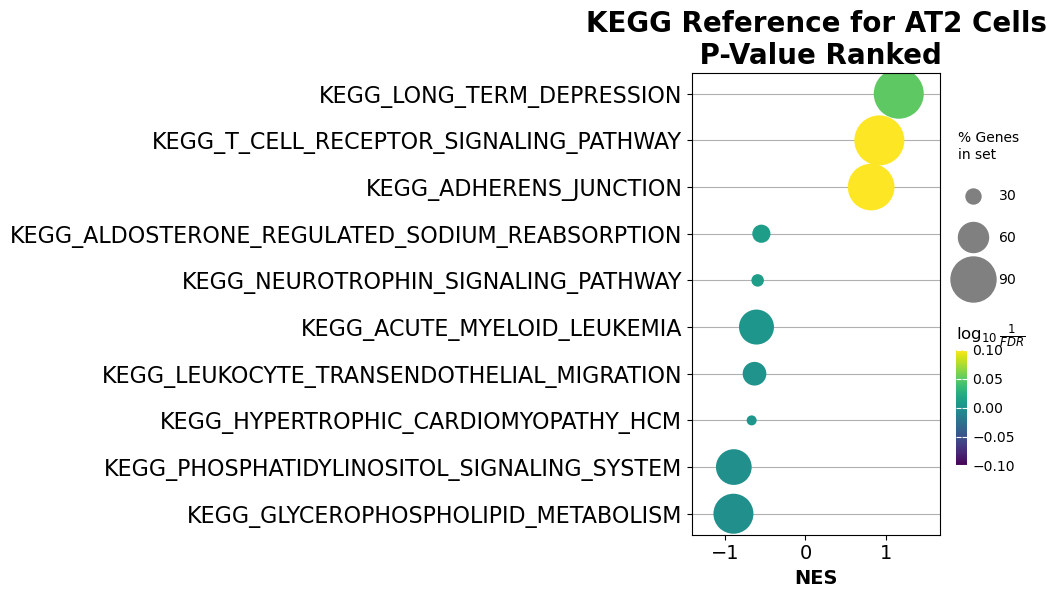

In [40]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG Reference for AT2 Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

### PID Pathways

Now repeat again using the pathway interaction database (PID)

In [41]:
prerank_list = de_genes_at2.sort_values("log2fc_ranks", ascending = False)
prerank_list[["gene_symbol", "log2fc_ranks"]]

gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/pid_at2_log2fc_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:22:26,320 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:22:26,324 [INFO] 0164 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:22:26,324 [INFO] 0032 gene_sets used for further statistical testing.....
2025-07-17 12:22:26,325 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:22:27,016 [INFO] Congratulations. GSEApy runs successfully................



In [42]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,PID_INSULIN_PATHWAY,0.468254,1.556515,0.031746,0.226358,0.047,11/11,53.51%,IRS1;SORBS1;NCK2;GRB10;EXOC6;SGK1;PTPN1;FOXO3;...
1,prerank,PID_ERBB1_DOWNSTREAM_PATHWAY,0.319417,1.353755,0.030303,0.305369,0.13,14/14,68.35%,EGR1;DUSP6;MAP3K1;FOS;DIAPH3;PIK3CD;PRKCA;GRB2...
2,prerank,PID_INTEGRIN3_PATHWAY,-0.48738,-1.219132,0.181631,1.0,0.977,8/14,35.06%,KDR;EDIL3;PLAUR;TNC;PDGFRB;COL1A1;PDGFB;FBN1
3,prerank,PID_SYNDECAN_1_PATHWAY,0.290258,1.208167,0.162791,0.408582,0.234,14/14,71.24%,COL5A2;COL4A4;COL4A3;COL5A1;COL8A1;COL15A1;COL...
4,prerank,PID_FGF_PATHWAY,-0.485421,-1.133926,0.296692,1.0,0.997,9/10,50.82%,RUNX2;FGFR2;NCAM1;PLAUR;SDC2;MET;PTK2B;PIK3R1;...


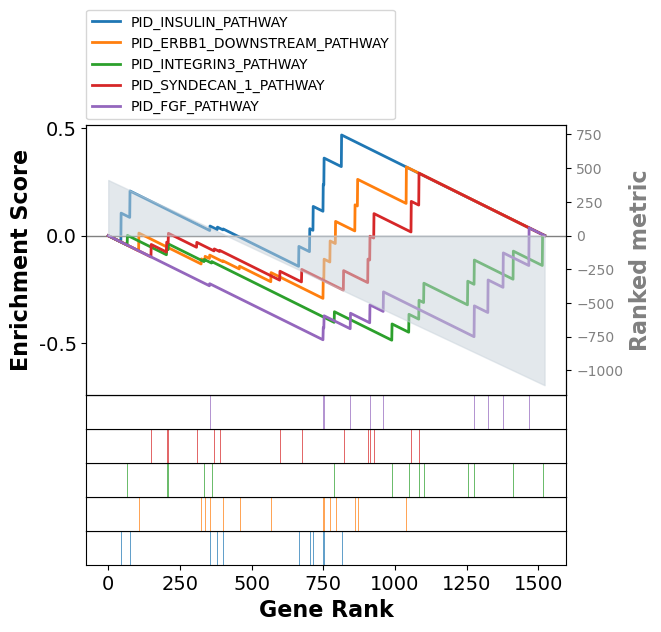

In [43]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

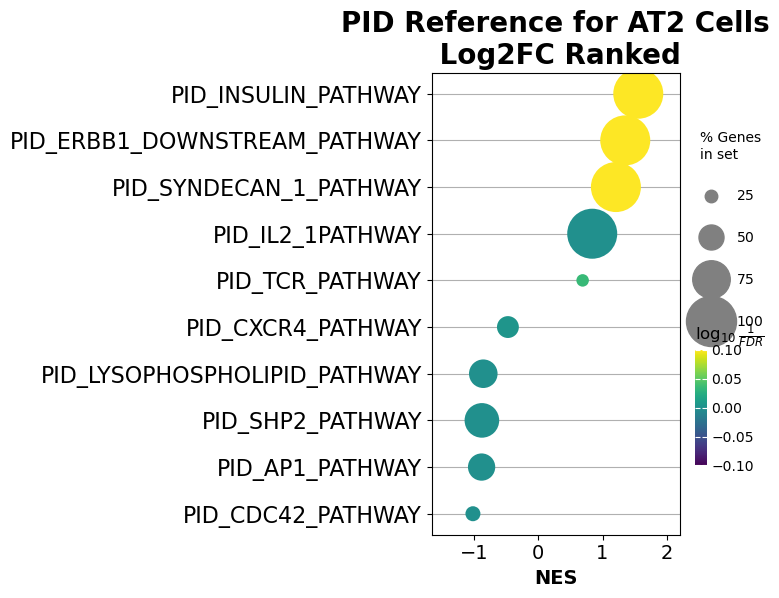

In [44]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='PID Reference for AT2 Cells\n Log2FC Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

In [45]:
prerank_list = de_genes_at2.sort_values("pval_ranks", ascending = False)
prerank_list[["gene_symbol", "pval_ranks"]]

gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/pid_at2_pval_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:22:28,696 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:22:28,700 [INFO] 0164 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:22:28,701 [INFO] 0032 gene_sets used for further statistical testing.....
2025-07-17 12:22:28,702 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:22:29,032 [INFO] Congratulations. GSEApy runs successfully................



In [46]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,PID_TCR_PATHWAY,0.353408,1.292582,0.089286,0.724808,0.169,12/12,64.94%,PAG1;CD247;PRKCE;CD86;HLA-DRA;MAP3K8;PRKCQ;GAB...
1,prerank,PID_CD8_TCR_PATHWAY,0.338187,1.193638,0.163265,0.581615,0.256,12/12,66.45%,PAG1;CD247;PRKCE;CD86;B2M;MAP3K8;PRKCQ;GRB2;LC...
2,prerank,PID_SYNDECAN_1_PATHWAY,-0.458243,-1.144594,0.295407,1.0,0.994,3/14,11.82%,COL12A1;COL6A2;COL14A1
3,prerank,PID_BETA_CATENIN_NUC_PATHWAY,-0.447076,-1.1279,0.306653,1.0,0.995,6/14,31.58%,KCNIP4;TBL1X;VCAN;CAMK4;TLE4;MT-CO2
4,prerank,PID_ARF6_TRAFFICKING_PATHWAY,-0.467823,-1.09895,0.338028,1.0,0.997,2/10,17.40%,PLD1;ITGA2


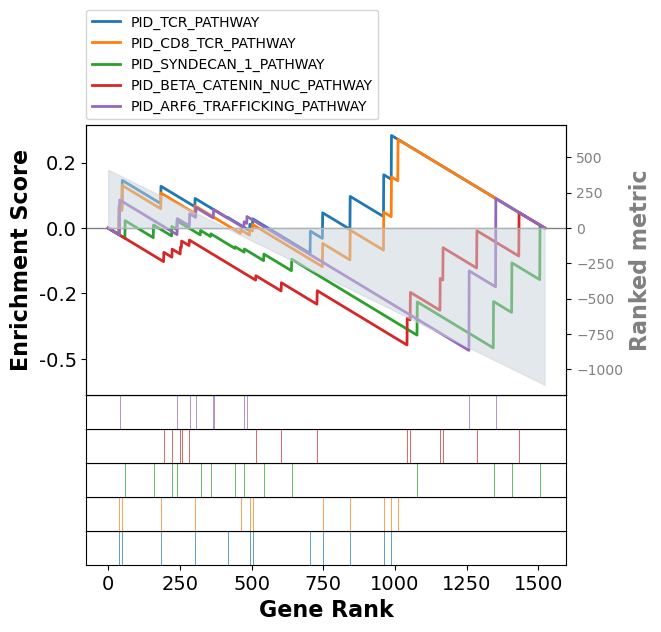

In [47]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

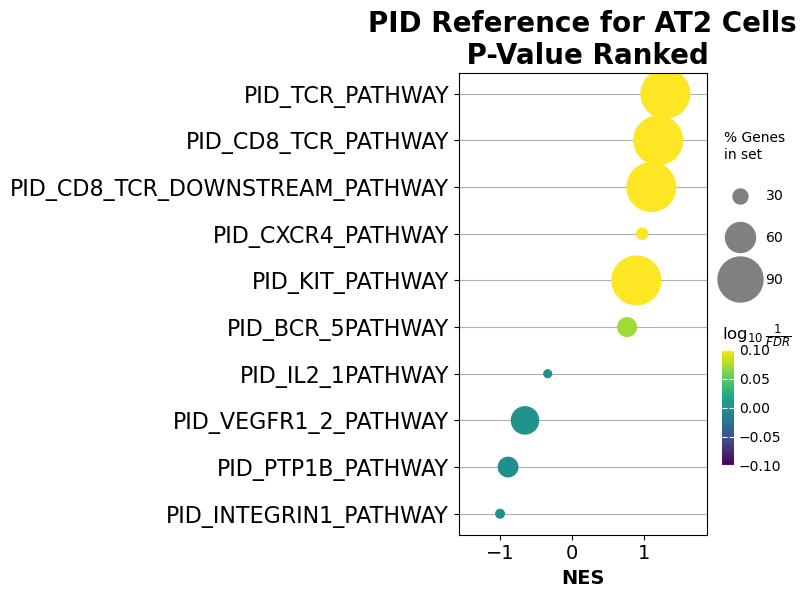

In [48]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='PID Reference for AT2 Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

## Macrophage Cells

### Hallmark Pathways

In [49]:
prerank_list = de_genes_macs.sort_values("log2fc_ranks", ascending = False)
prerank_list[["gene_symbol", "log2fc_ranks"]]

gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/hallmark_macs_log2fc_ranking", # don't write to disk
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:22:30,706 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:22:30,737 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:22:30,738 [INFO] 0050 gene_sets used for further statistical testing.....
2025-07-17 12:22:30,738 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:22:38,539 [INFO] Congratulations. GSEApy runs successfully................



In [50]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_INFLAMMATORY_RESPONSE,-0.458319,-1.386319,0.0,0.149051,0.137,78/155,29.96%,INHBA;PROK2;APLNR;ITGB8;IL1A;CXCL8;ADGRE1;IL1B...
1,prerank,HALLMARK_TGF_BETA_SIGNALING,-0.482436,-1.372899,0.001,0.091031,0.166,29/51,31.08%,ID3;THBS1;BCAR3;ID1;SMAD7;HIPK2;CDKN1C;SPTBN1;...
2,prerank,HALLMARK_IL6_JAK_STAT3_SIGNALING,-0.472407,-1.370416,0.003,0.063021,0.172,37/71,32.72%,IL1R2;CXCL1;IL3RA;IL1B;ACVRL1;IRF1;TLR2;TNFRSF...
3,prerank,HALLMARK_MYOGENESIS,-0.442347,-1.323499,0.001,0.08853,0.304,68/121,36.25%,APLNR;PPP1R3C;FHL1;GJA5;SVIL;HBEGF;COX7A1;MYL6...
4,prerank,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,-0.432059,-1.306252,0.0,0.090231,0.363,76/148,32.79%,INHBA;CXCL1;TNC;CCN1;ANPEP;COL12A1;CXCL8;PCOLC...


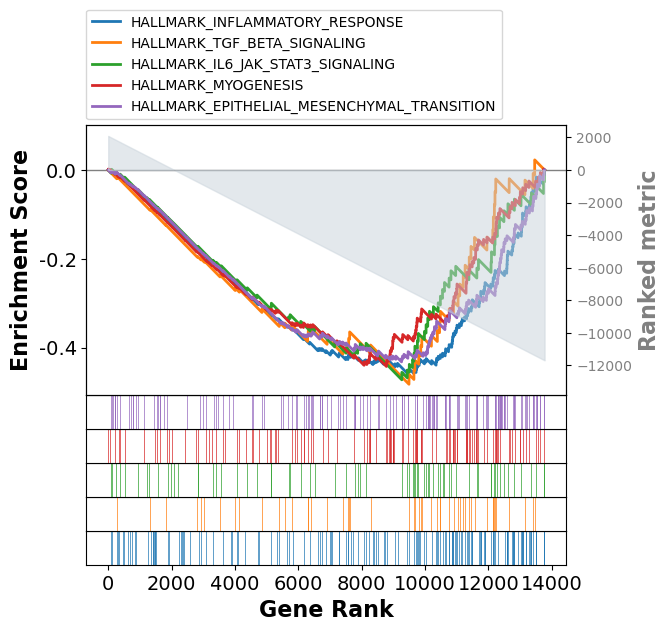

In [51]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

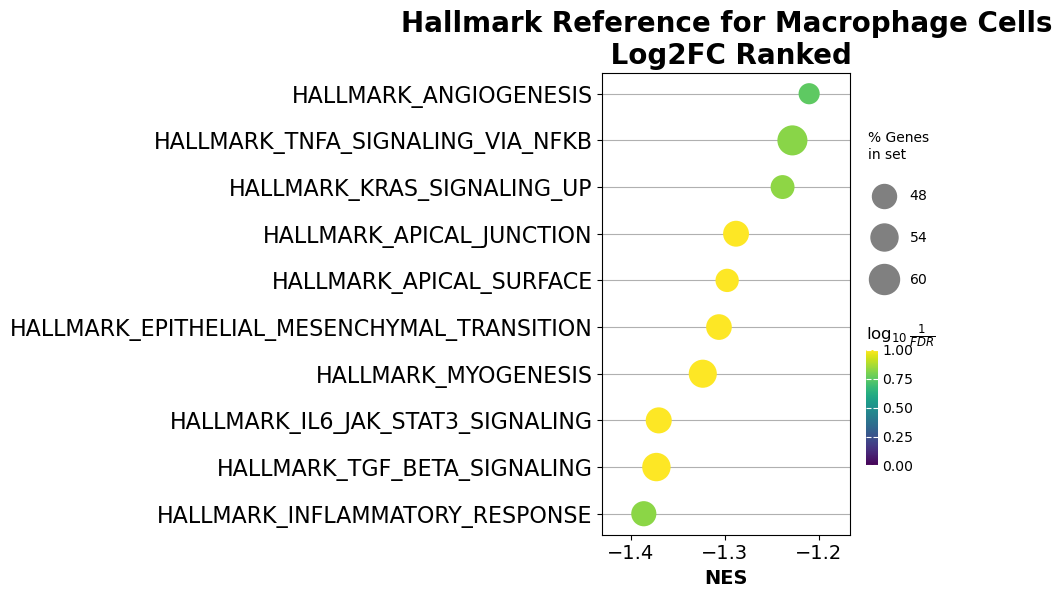

In [52]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='Hallmark Reference for Macrophage Cells\n Log2FC Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

In [53]:
prerank_list = de_genes_macs.sort_values("pval_ranks", ascending = False)
prerank_list[["gene_symbol", "pval_ranks"]]

gmt = msig.get_gmt(category = "h.all", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/hallmark_macs_pval_ranking", # don't write to disk
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:22:40,269 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:22:40,290 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:22:40,290 [INFO] 0050 gene_sets used for further statistical testing.....
2025-07-17 12:22:40,291 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:22:53,756 [INFO] Congratulations. GSEApy runs successfully................



In [54]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_UV_RESPONSE_DN,-0.542327,-1.63071,0.0,0.005002,0.005,73/130,24.58%,PTPRM;PPARG;RUNX1;PEX14;DLC1;NRP1;ATXN1;APBB2;...
1,prerank,HALLMARK_IL6_JAK_STAT3_SIGNALING,-0.549052,-1.605252,0.0,0.003001,0.006,43/71,32.13%,CD44;IL3RA;TLR2;GRB2;PIK3R5;PTPN2;CBL;IL1R2;PT...
2,prerank,HALLMARK_TGF_BETA_SIGNALING,-0.540318,-1.528479,0.0,0.005669,0.017,25/51,12.68%,HIPK2;SPTBN1;RAB31;BCAR3;THBS1;NCOR2;SMURF1;BM...
3,prerank,HALLMARK_PI3K_AKT_MTOR_SIGNALING,-0.51501,-1.524371,0.0,0.004252,0.017,49/93,27.62%,GRB2;EGFR;SMAD2;GSK3B;CAB39;ITPR2;ACACA;ACTR2;...
4,prerank,HALLMARK_PROTEIN_SECRETION,-0.469711,-1.391054,0.0,0.029611,0.136,64/89,43.18%,SGMS1;EGFR;RAB2A;ARFGEF1;DST;MON2;GOLGA4;SNX2;...


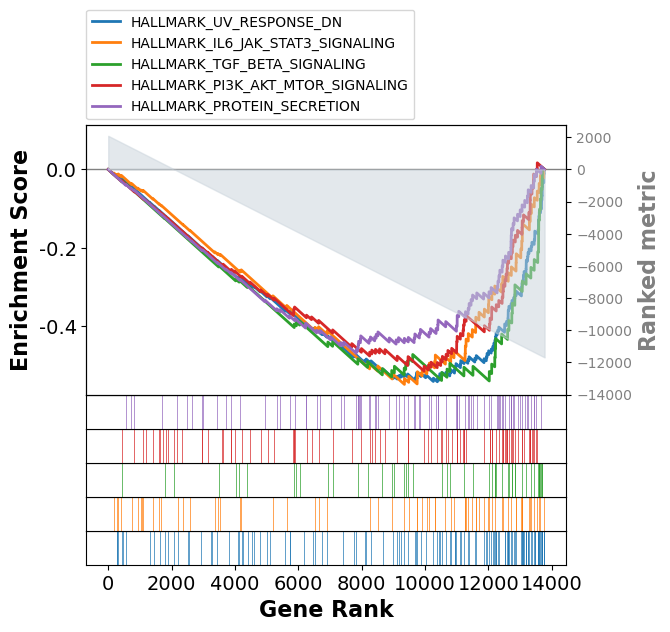

In [55]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

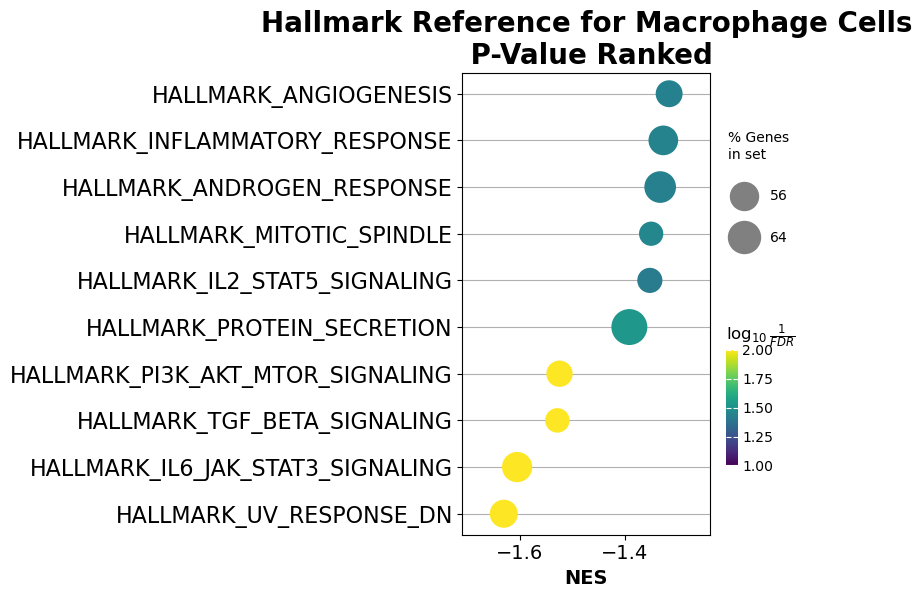

In [56]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='Hallmark Reference for Macrophage Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

### KEGG Pathways

In [57]:
gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
prerank_list = de_genes_macs.sort_values("log2fc_ranks", ascending = False)
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/kegg_macs_log2fc_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:22:55,617 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:22:55,637 [INFO] 0014 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:22:55,638 [INFO] 0172 gene_sets used for further statistical testing.....
2025-07-17 12:22:55,638 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:23:09,369 [INFO] Congratulations. GSEApy runs successfully................



In [58]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_RIBOSOME,-0.700992,-2.0662,0.0,0.0,0.0,71/84,21.11%,RPL36AL;FAU;RPL24;RPL11;RPL19;RPS23;RPS12;RPS1...
1,prerank,KEGG_STEROID_BIOSYNTHESIS,0.503161,1.700402,0.0,0.033613,0.006,11/11,49.72%,MSMO1;HSD17B7;TM7SF2;DHCR24;CYP51A1;LIPA;SOAT1...
2,prerank,KEGG_ARRHYTHMOGENIC_RIGHT_VENTRICULAR_CARDIOMY...,-0.55783,-1.588831,0.0,0.089254,0.152,33/50,28.32%,CACNG4;ITGB8;TCF7L2;TCF7;PKP2;CACNA2D4;ITGA10;...
3,prerank,KEGG_HEMATOPOIETIC_CELL_LINEAGE,-0.546339,-1.536883,0.0,0.12391,0.302,24/46,26.84%,IL1R2;CD5;MME;ANPEP;IL1A;IL3RA;CD7;IL1B;IL7R;H...
4,prerank,KEGG_STEROID_HORMONE_BIOSYNTHESIS,-0.60597,-1.506648,0.011145,0.139521,0.399,12/15,33.36%,AKR1C2;SULT1E1;CYP3A5;AKR1C3;HSD11B2;AKR1C1;HS...


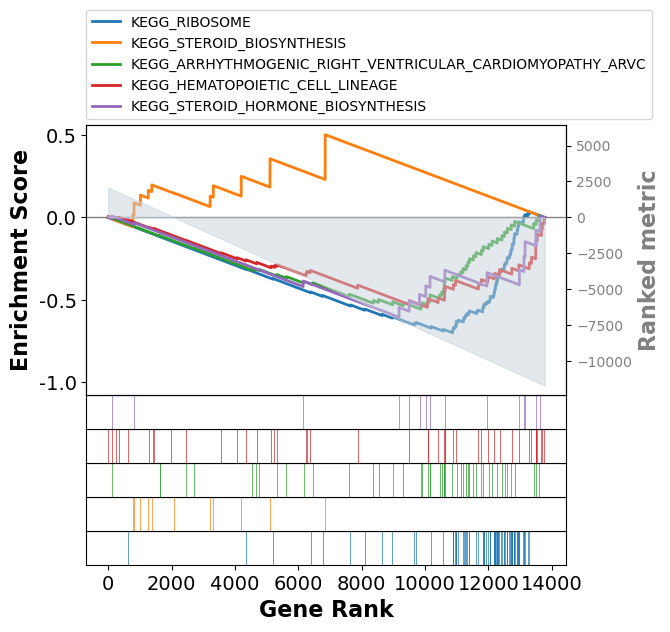

In [59]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

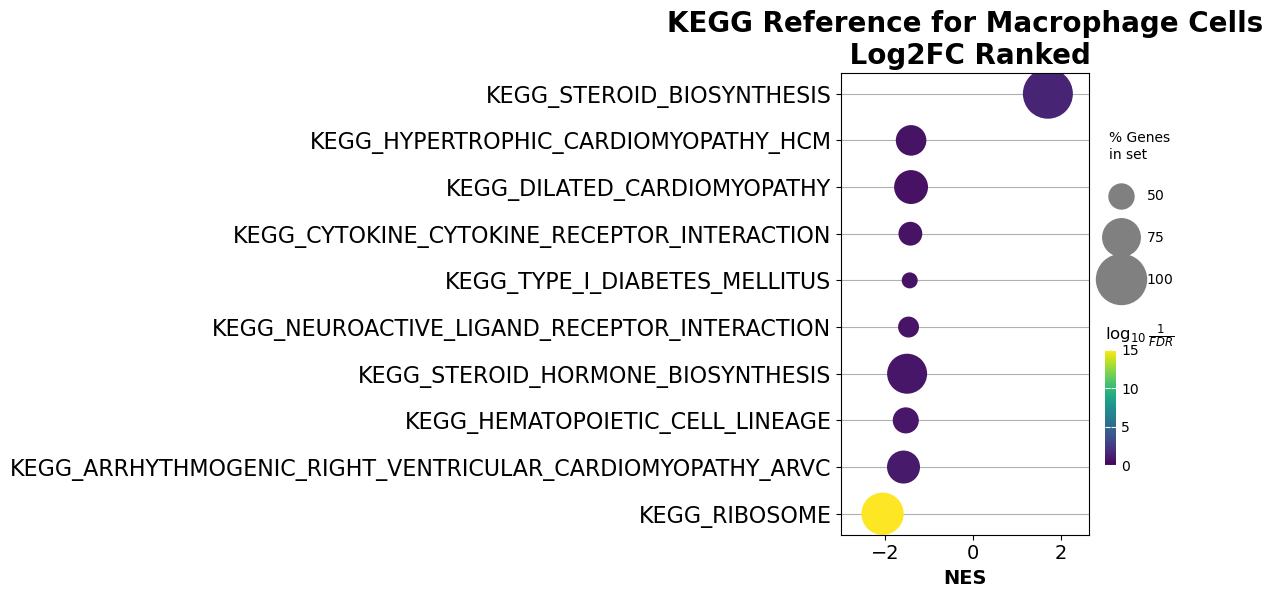

In [60]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG Reference for Macrophage Cells\n Log2FC Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

In [61]:
gmt = msig.get_gmt(category = "c2.cp.kegg_legacy", dbver = "2025.1.Hs")
prerank_list = de_genes_macs.sort_values("pval_ranks", ascending = False)
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/kegg_macs_pval_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:23:11,225 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:23:11,278 [INFO] 0014 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:23:11,280 [INFO] 0172 gene_sets used for further statistical testing.....
2025-07-17 12:23:11,280 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:23:29,947 [INFO] Congratulations. GSEApy runs successfully................



In [62]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_RIBOSOME,-0.792824,-2.32153,0.0,0.0,0.0,73/84,13.01%,RPL41;RPL11;RPS12;RPL10;RPLP1;RPL13A;RPS18;RPS...
1,prerank,KEGG_STEROID_BIOSYNTHESIS,0.573276,1.790865,0.0,0.0,0.0,11/11,42.72%,MSMO1;HSD17B7;DHCR24;CYP51A1;TM7SF2;LIPA;EBP;N...
2,prerank,KEGG_ADHERENS_JUNCTION,-0.591258,-1.728027,0.0,0.009982,0.02,44/67,27.25%,TCF7L2;PTPRM;TGFBR2;LMO7;CTNNA1;CTNNB1;FER;PTP...
3,prerank,KEGG_LEUKOCYTE_TRANSENDOTHELIAL_MIGRATION,-0.566469,-1.672038,0.0,0.014973,0.045,56/88,27.33%,RAP1B;CTNNA1;MAPK14;CTNNB1;PECAM1;VCL;ACTN4;PI...
4,prerank,KEGG_GNRH_SIGNALING_PATHWAY,-0.571636,-1.667603,0.0,0.011479,0.046,47/71,29.35%,GNAQ;CAMK2D;MAPK14;GRB2;EGFR;ITPR2;PRKCA;MAP3K...


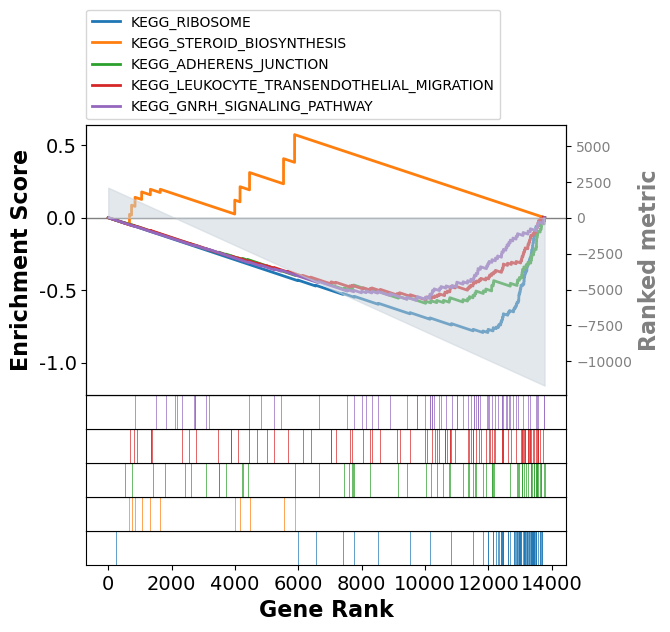

In [63]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

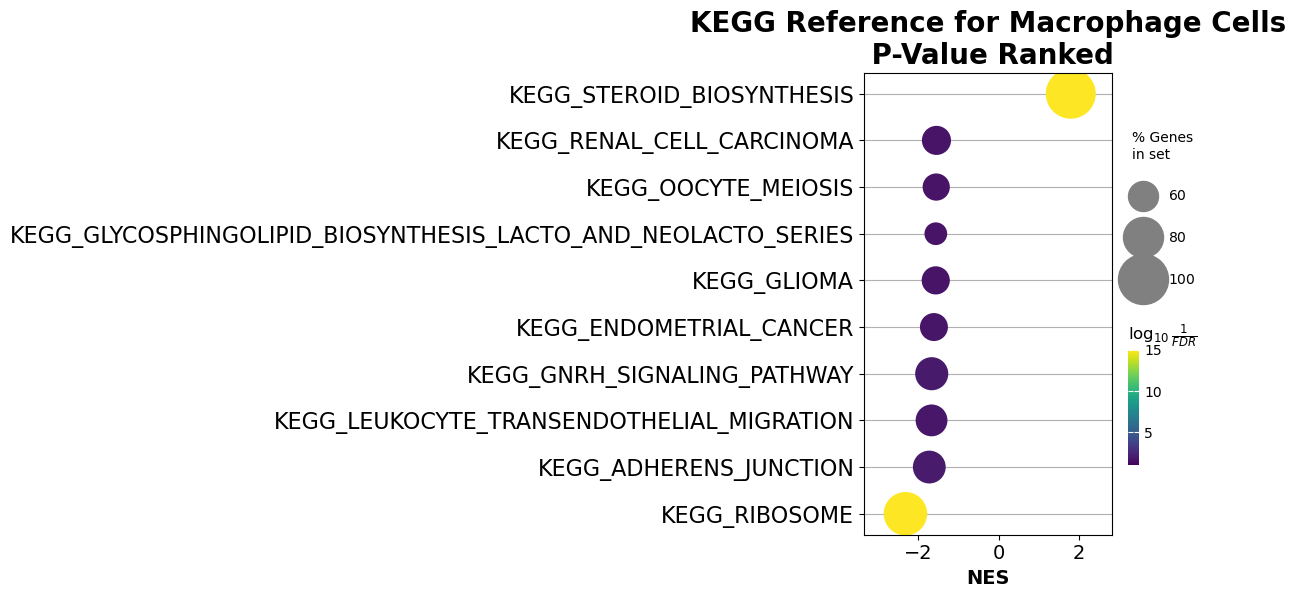

In [64]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG Reference for Macrophage Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

### PID Pathways

In [65]:
prerank_list = de_genes_macs.sort_values("log2fc_ranks", ascending = False)
prerank_list[["gene_symbol", "log2fc_ranks"]]

gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "log2fc_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/pid_macs_log2fc_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:23:31,687 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:23:31,709 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:23:31,710 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-17 12:23:31,710 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:23:41,060 [INFO] Congratulations. GSEApy runs successfully................



In [66]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,PID_ERBB_NETWORK_PATHWAY,-0.659615,-1.606024,0.002043,0.154525,0.13,6/13,13.48%,NRG3;EREG;HBEGF;NRG1;EGFR;NRG4
1,prerank,PID_EPHA_FWDPATHWAY,-0.575208,-1.508788,0.005015,0.308047,0.425,13/23,29.38%,ARHGEF15;EPHA2;FYN;YES1;PLCG1;LYN;LCK;HCK;CRK;...
2,prerank,PID_INTEGRIN3_PATHWAY,-0.53751,-1.454331,0.007,0.430797,0.682,18/33,21.15%,TNC;CCN1;THBS1;FN1;KDR;COL4A6;EDIL3;COL4A1;LAM...
3,prerank,PID_INTEGRIN1_PATHWAY,-0.50735,-1.436338,0.001,0.400862,0.74,31/53,29.23%,TNC;CSPG4;THBS1;FN1;COL4A6;COL4A1;LAMB1;JAM2;L...
4,prerank,PID_AMB2_NEUTROPHILS_PATHWAY,-0.531259,-1.420137,0.009,0.399558,0.796,20/30,33.82%,CCN2;JAM2;MMP2;FYN;JAM3;YES1;RAP1B;AKT1;AGER;L...


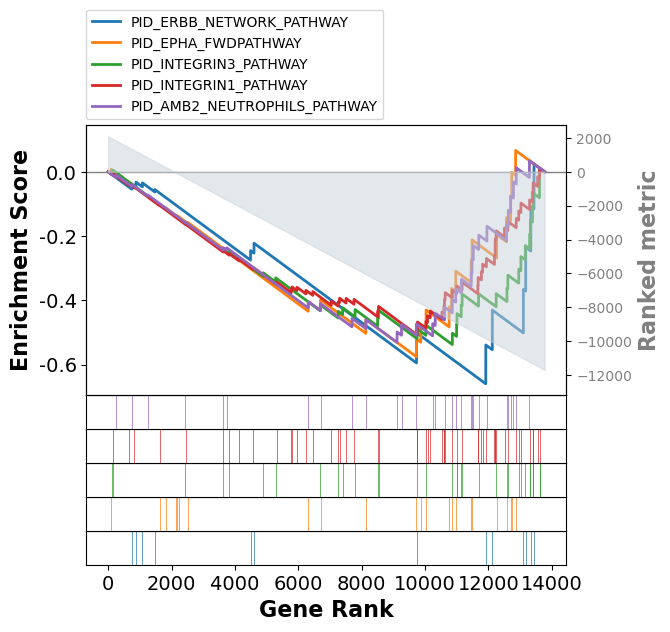

In [67]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

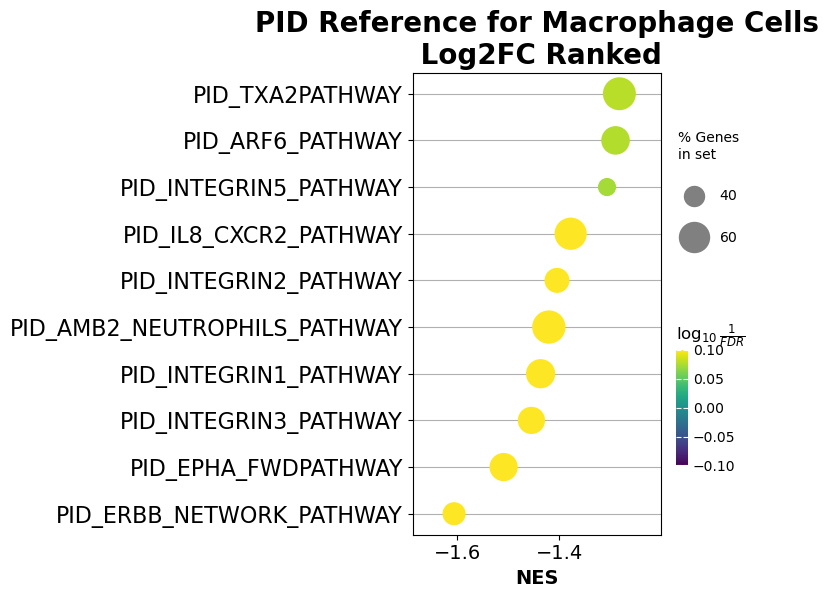

In [68]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='PID Reference for Macrophage Cells\n Log2FC Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

In [69]:
prerank_list = de_genes_macs.sort_values("pval_ranks", ascending = False)
prerank_list[["gene_symbol", "pval_ranks"]]

gmt = msig.get_gmt(category = "c2.cp.pid", dbver = "2025.1.Hs")
pre_res = gp.prerank(rnk = prerank_list[["gene_symbol", "pval_ranks"]], 
                     gene_sets = gmt,
                     threads = 4,
                     min_size = 10,
                     max_size = 500,
                     permutation_num = 1000, # reduce number to speed up testing
                     outdir = f"{project_dir}/output/09_gsea/pid_macs_pval_ranking", 
                     graph_num = 25,
                     format = "png",
                     verbose=True, # see what's going on behind the scenes
                    )

2025-07-17 12:23:42,941 [INFO] Parsing data files for GSEA.............................
2025-07-17 12:23:42,961 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=10
2025-07-17 12:23:42,962 [INFO] 0191 gene_sets used for further statistical testing.....
2025-07-17 12:23:42,962 [INFO] Start to run GSEA...Might take a while..................
2025-07-17 12:24:01,710 [INFO] Congratulations. GSEApy runs successfully................



In [70]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,PID_FAK_PATHWAY,-0.634248,-1.817258,0.0,0.00301,0.003,44/57,27.00%,RAP1B;BRAF;ASAP1;RASA1;GRB2;VCL;RAP1A;DOCK1;EL...
1,prerank,PID_CDC42_PATHWAY,-0.630853,-1.811532,0.0,0.003512,0.007,40/62,22.59%,ARPC2;BRAF;CTNNA1;DLG1;MAPK14;CTNNB1;GSK3B;LIM...
2,prerank,PID_TGFBR_PATHWAY,-0.627745,-1.766921,0.0,0.003679,0.011,36/49,25.45%,SPTBN1;TGFBR2;SMURF1;CTNNB1;GRB2;CAV1;SMAD2;YA...
3,prerank,PID_AMB2_NEUTROPHILS_PATHWAY,-0.648729,-1.765172,0.0,0.00276,0.011,20/30,21.70%,RAP1B;LYN;HCK;RAP1A;ROCK1;FYN;LRP1;NFKB1;YES1;...
4,prerank,PID_RHOA_PATHWAY,-0.633141,-1.757984,0.0,0.002408,0.012,29/38,29.52%,VCL;PPP1R12A;LIMK2;DIAPH1;PKN2;PIP5K1B;ROCK1;M...


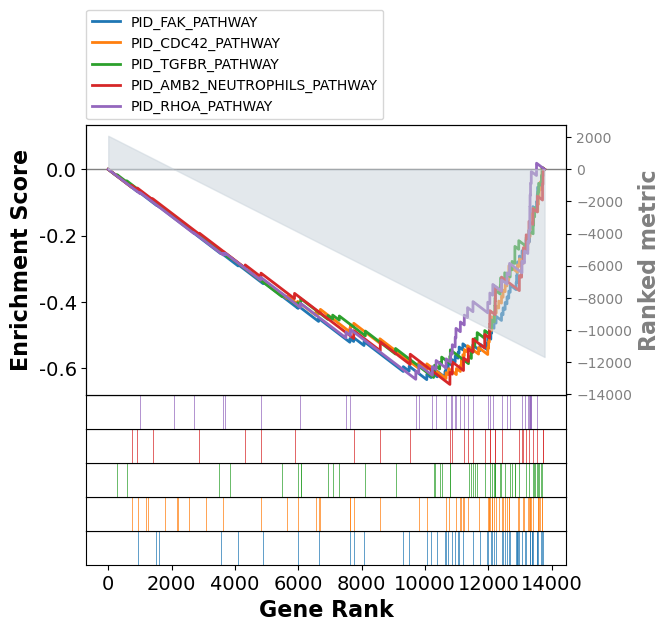

In [71]:
# Swoosh plot of enrichment scores
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[0:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

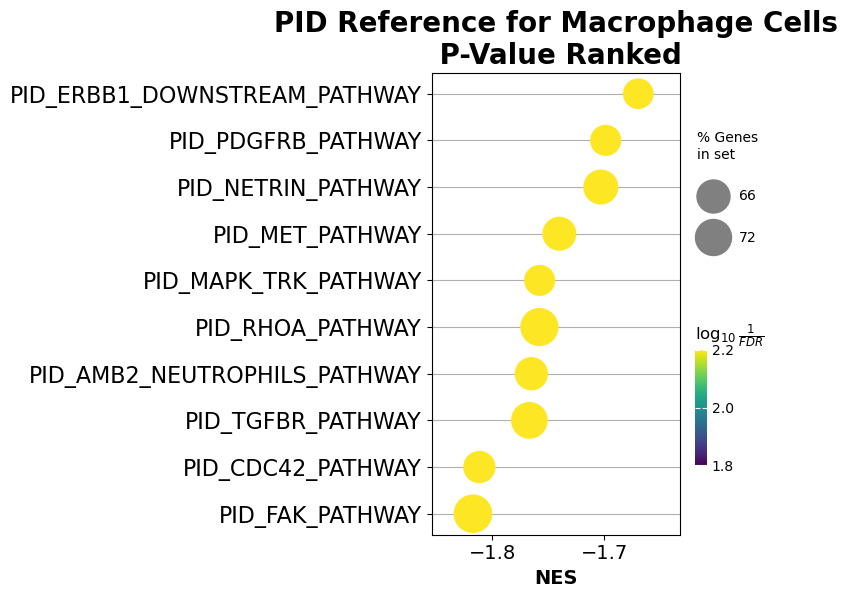

In [72]:
# Dot plot
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='PID Reference for Macrophage Cells\n P-Value Ranked',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)